# Онлайн-продажи

### Шаг 1. Импортируйте библиотеки

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### Шаг 2. Импортируем датасет
[ссылка](https://drive.google.com/file/d/15TDU30hgLI_0db8Li_oUQBBPAPik8O-8/view?usp=sharing) для загрузки

In [77]:
path = '../../../../datasets/Online_Retail.csv'
online_rt = pd.read_csv(path,  encoding='latin1')

### Шаг 2. Импортируем датасет
[ссылка](https://drive.google.com/file/d/15TDU30hgLI_0db8Li_oUQBBPAPik8O-8/view?usp=sharing) для загрузки

### Шаг 3. Прочитайте в переменную online_rt
Если вышла ошибка кодировки, задайте `encoding = 'latin1'`

### Шаг 4. Удалите заказы с отрицательным Quantity. Сколько таких заказов?

In [78]:
print(online_rt.loc[online_rt['Quantity'] < 0].shape[0])
online_rt = online_rt.loc[online_rt['Quantity'] >= 0]

10624


### Шаг 5. Добавьте колонку Revenue = Quantity * UnitPrice

In [79]:
online_rt = online_rt.assign(Revenue = online_rt.loc[:, 'Quantity']*online_rt.loc[:, 'UnitPrice'])

### Шаг 6. Приведите колонку InvoiceDate в правильный формат
`pd.to_datetime(df[col])`

In [80]:
online_rt['InvoiceDate'] = pd.to_datetime(pd.to_datetime(online_rt['InvoiceDate']))

### Шаг 7. Нарисуйте bar chart с 10 странами с максимальным Revenue

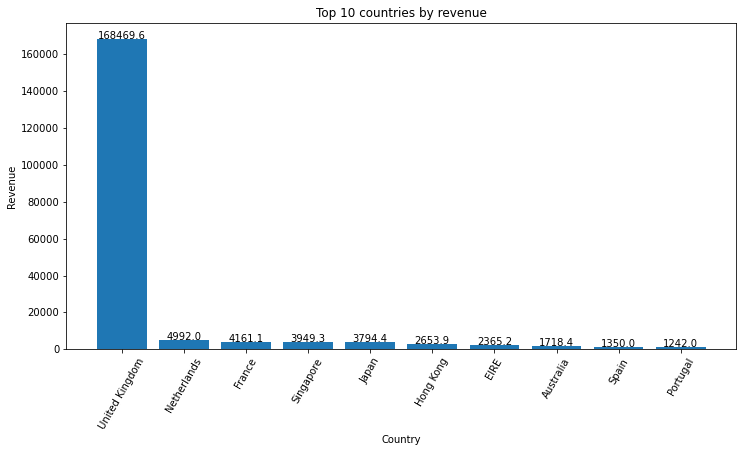

In [149]:
fig, ax = plt.subplots(figsize = (12, 6))

ax.bar('Country', 'Revenue', data=online_rt.sort_values(by = 'Revenue', ascending=False).drop_duplicates('Country').head(10))
ax.set(
    xlabel = 'Country',
    ylabel = 'Revenue',
    title = 'Top 10 countries by revenue'
)

for i, j in enumerate(online_rt.sort_values(by = 'Revenue', ascending=False).drop_duplicates('Country').head(10)[['Country', 'Revenue']].to_numpy()):
    ax.text(i, j[1], round(j[1], 1), horizontalalignment = 'center')
plt.xticks(rotation = 60)
plt.show()

### Шаг 8. Постройте scatterplot с sum(Quantity) и mean(UnitPrice) по каждому товару

### Шаг 9. Постройте линейные графики изменения во времени общей суммы продаж и количества заказов по топ-10 странам по Revenue

https://kanoki.org/2020/05/26/dataframe-groupby-date-and-time/

### Шаг 10. Проверьте, есть ли покупатели, которые делали заказы в нескольких странах

### Шаг 11. Менялись ли цена на одни и те же товары? Увеличивало ли продажи (по количеству и общей цене) снижение цены? Уменьшало ли продажи увеличение цены?

### Бонус: исследуйте датасет дальше, ставя вопросы и отвечая на них с помощью графиков